# Ray 调度最小实现：同步与异步

把 [03 篇 训推协同](../../../doc/05-RL/03-训推协同%20-%20同步与异步.md) 控制一章的三层写成 toy 代码，本地 CPU 跑。两处简化：

- 一组卡当成一个整体，只起一个 actor：不模拟组内多卡，也就不用 worker group 切片、拼回
- 各阶段用 `time.sleep` 模拟，时长 = 正文实测 / 50；权重用一个版本号整数代替

概念和代码的对应：

| 自上而下 | 是什么 | 代码里 |
| --- | --- | --- |
| driver | 主进程，决定每步算什么、数据发给谁 | `sync_step`、`run_async` 的循环 |
| 一组卡 | 常驻进程，装着引擎等 driver 派活；Ray 叫 actor | `@ray.remote class Worker`，`Worker.remote()` 起一个 |
| 派活 | `.remote()` 发出去，立刻返回凭据（future），不等 | `w.rollout.remote(x)` |
| 取结果 | `ray.get(凭据)` 才等 | `ray.get(ref)` |

下面按这张表自上而下的反方向走：先起一组卡，看派活和取结果长什么样，再写 driver 的三段调度代码，最后逐段验收。

## 0. 准备

In [43]:
# 1. 安装中文字体
!apt-get -y install fonts-wqy-zenhei

# 2. 导入库与 Matplotlib 字体配置
import time, random, collections, logging, warnings
import ray
import matplotlib as mpl
import matplotlib.pyplot as plt
import shutil

# 强制刷新 Matplotlib 字体管理器，加载刚安装的系统字体
from matplotlib import font_manager
import os

# 重建字体索引缓存
font_manager._load_fontmanager(try_read_cache=False)

# 显式添加字体路径以防系统缓存未生效
font_path = '/usr/share/fonts/truetype/wqy/wqy-zenhei.ttc'
if os.path.exists(font_path):
    font_manager.fontManager.addfont(font_path)

# 设置文泉驿正黑为首选字体
plt.rcParams['font.family'] = ['WenQuanYi Zen Hei', 'Hiragino Sans GB', 'Arial Unicode MS', 'DejaVu Sans']   # Colab 用文泉驿，Mac 本地落到 Hiragino
plt.rcParams['axes.unicode_minus'] = False  # 正常显示负号

warnings.filterwarnings('ignore')
ray.init(ignore_reinit_error=True, num_cpus=8, log_to_driver=False, logging_level=logging.ERROR)
print("Ray 运行版本:", ray.__version__)

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-wqy-zenhei is already the newest version (0.9.45-8).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


Ray 运行版本: 2.59.0


### 耗时配置 ｜ 正文同步、异步两章的案例

正文实测（秒）除以 50。同步是 16 卡共池、一步 1024 条；异步是生成 2 + 判分 6 + 训练 8、一步 512 条。Ray 每次调用约 10 ms，实测会比理论多几个百分点。

In [44]:
SYNC = dict(rollout=0.40, old=0.18, ref=0.18, update=0.27, sync=0.12,    # update 分两个 mini-batch，各 0.27
            J=0.96, tail_p=0.0, tail=0.0)    # 打分一批 53 s，提前 5 s 开始：rollout 结束后还要 48 s

ASYNC = dict(rollout=0.36, old=0.16, ref=0.16, update=0.50, sync=0.12,
             J=0.46,                         # 一批从发出到分数齐中位 41 s，减去生成的 18 s
             tail_p=0.15, tail=0.60)         # 偶发拖尾批：整批多等 30 s

# 甘特图配色，和正文一致
COLOR = {'rollout': '#bbdefb', 'old_logp': '#d1c4e9', 'ref_logp': '#d1c4e9', 'update': '#9575cd',
         '打分': '#fffbdc', '等打分': '#e0e0e0', '权重同步': '#e0e0e0'}

## 1. 一组卡：Worker 和 Judge

表的第二行。Worker 的四个方法对应前言阶段表的四个阶段；Judge 是打分服务；最后是画甘特的小函数，配色和正文一致。

In [45]:
class WorkerImpl:
    """一组卡。共池时同一个实例轮流当推理引擎和训练引擎，分池时生成、训练各起一个。

    参数:
    - cfg: 各阶段耗时，键为 rollout / old / ref / update / sync
    - version: 初始权重版本号，toy 里权重就是这个整数
    """
    def __init__(self, cfg, version=0):
        self.cfg, self.version = cfg, version

    def rollout(self, prompts):
        """推理态：生成一批 response。

        参数:
        - prompts: list，长度为这批的条数
        返回:
        - batch: dict，n 为条数，bv 为生成时的权重版本（behavior version），t 为起止时间
        """
        t0 = time.time()
        time.sleep(self.cfg['rollout'])                       # 生成的时间由最长的 response 决定
        return dict(n=len(prompts), bv=self.version, t=(t0, time.time()))

    def rollout_one(self, prompt, mean=0.36):
        """流式用：一次生成一条，长度随机、带长尾。返回单条，字段同 rollout。"""
        t0 = time.time()
        time.sleep(min(random.expovariate(1 / mean), 1.0))   # 指数分布模拟长尾，封顶 1.0
        return dict(n=1, bv=self.version, t=(t0, time.time()))

    def logp(self, batch):
        """训练态的两个前向：actor 算 old_logp，ref 算 ref_logp。不需要分数。

        返回:
        - ((t0, t1), (t1, t2)): 两段的起止时间
        """
        t0 = time.time(); time.sleep(self.cfg['old']); t1 = time.time(); time.sleep(self.cfg['ref'])
        return ((t0, t1), (t1, time.time()))

    def update(self, batch, scores):
        """前向 + 反向，一个 mini-batch，权重版本号 +1。需要分数。

        返回:
        - dict: version 为更新前的版本（算 Δv 用），t 为起止时间
        """
        t0 = time.time(); time.sleep(self.cfg['update'])
        before = self.version
        self.version += 1
        return dict(version=before, t=(t0, time.time()))

    def get_version(self):
        return self.version

    def load_weights(self, version):
        """权重同步：训练引擎 → 推理引擎。共池是同卡交接，分池是跨卡传输，toy 里都只拷贝版本号。"""
        t0 = time.time(); time.sleep(self.cfg['sync'])
        self.version = version
        return (t0, time.time())


class JudgeImpl:
    """打分服务。同步案例里是外部服务，异步案例里是任务内的判分卡。

    参数:
    - cfg: J 为打分一批的耗时，tail_p / tail 为拖尾批的概率和额外耗时
    """
    def __init__(self, cfg, seed=0):
        self.cfg, self.rng = cfg, random.Random(seed)

    def score(self, batch):
        """打分一批。偶发拖尾批：有一条回答写满上限、失败重发，整批多等一截。"""
        t0 = time.time()
        d = self.cfg['J'] + (self.cfg['tail'] if self.rng.random() < self.cfg['tail_p'] else 0)
        time.sleep(d)
        return dict(scores=[1.0] * batch['n'], t=(t0, time.time()))

    def score_one(self, traj, mean=0.06):
        """流式用：打一条。"""
        t0 = time.time(); time.sleep(min(random.expovariate(1 / mean), 0.5))
        traj['score'] = 1.0; traj['t_score'] = (t0, time.time())
        return traj


Worker = ray.remote(WorkerImpl)                              # 一个 actor = 一组卡，方法串行执行
Judge = ray.remote(max_concurrency=8)(JudgeImpl)             # 判分服务允许几批同时打


def gantt(ev, title, t0, rows, t1=None):
    """画甘特。ev 为 (行, 标签, 起, 止) 列表，rows 给行的顺序，只画 [t0, t1] 内的事件。"""
    fig, ax = plt.subplots(figsize=(11, 0.55 * len(rows) + 1))
    for i, r in enumerate(rows):
        for row, label, s, e in ev:
            if row != r or e < t0 or (t1 and s > t1):
                continue
            key = next((k for k in COLOR if label.startswith(k)), None)
            color = COLOR.get(key) or ('#fffbdc' if r == '判分' else '#bbdefb')
            ax.broken_barh([(s - t0, e - s)], (i - 0.35, 0.7), facecolors=color, edgecolors='#9e9e9e')
            if e - s > 0.1:                                             # 太短的条不写字
                ax.text(s - t0 + (e - s) / 2, i, label, ha='center', va='center', fontsize=8)
    ax.set_yticks(range(len(rows))); ax.set_yticklabels(rows); ax.invert_yaxis()
    ax.set_xlabel('s（正文时间 / 50）'); ax.set_title(title); ax.grid(axis='x', alpha=.3)
    plt.show()

## 2. 派活与取结果

表的第三、四行。`.remote()` 发出去立刻返回凭据，`ray.get` 才等。

In [46]:
w = Worker.remote(SYNC)                       # 一组卡：起一个常驻进程，w 是句柄
t0 = time.time()
ref = w.rollout.remote(list(range(1024)))     # 派活：立刻返回凭据，不等
print(f'发出去用了 {time.time() - t0:.3f} s，拿到的是 {type(ref).__name__}')
batch = ray.get(ref)                          # 取结果：这时才等 rollout 做完
print(f'取结果等了 {time.time() - t0:.2f} s，batch 的权重版本 bv = {batch["bv"]}')

发出去用了 0.002 s，拿到的是 ObjectRef
取结果等了 0.70 s，batch 的权重版本 bv = 0


## 3. driver：三段调度代码

表的第一行。只定义，跑在第 4 节。

### 3.1 同步 ｜ 正文同步一章

一个 Worker 轮流当推理引擎和训练引擎；打分先发后取，和两个前向重叠。

In [47]:
def sync_step(w, judge, prompts, n_mb=2):
    """共池同步的一个 step。

    参数:
    - w: Worker actor，这组卡
    - judge: 外部打分服务
    - n_mb: update 分几个 mini-batch
    返回:
    - ev: 各段事件 (行, 标签, 起, 止)，画图和核时间用
    - dvs: 每个 mini-batch 的 Δv
    """
    ev = []
    batch = ray.get(w.rollout.remote(prompts))                            # 1. rollout，推理态
    ev.append(('卡', 'rollout', *batch['t']))
    score_ref = judge.score.remote(batch)                                 # 2. 发给外部打分，立刻返回 future
    o, r = ray.get(w.logp.remote(batch))                                  # 3. 两个前向，和打分重叠
    ev += [('卡', 'old_logp', *o), ('卡', 'ref_logp', *r)]
    tw = time.time(); sc = ray.get(score_ref); ev.append(('卡', '等打分', tw, time.time()))   # 4. update 要分数，等
    ev.append(('外部打分', '打分', *sc['t']))
    dvs = []
    for i in range(n_mb):                                                 # 5. update，分 mini-batch 几轮
        up = ray.get(w.update.remote(batch, sc['scores']))
        ev.append(('卡', f'update {i + 1}', *up['t'])); dvs.append(up['version'] - batch['bv'])
    v = ray.get(w.get_version.remote())
    ev.append(('卡', '权重同步', *ray.get(w.load_weights.remote(v))))      # 6. 权重同步，同卡交接
    return ev, dvs

### 3.2 异步 ｜ 正文异步一章

- 生成、判分、训练各一个 actor
- `inflight` 里最多 L 批在途，就是"领先 L 批"：trainer 取走一批，生成侧补一批
- 每 N 次 update 给生成侧推一次权重

In [48]:
def run_async(gen, judge, train, n_steps, L=1, N=2, bs=512):
    """异步训练 n_steps 步。

    参数:
    - gen / judge / train: 三组卡
    - L: 生成领先几批（在途批数上限）
    - N: 几次 update 同步一次权重
    返回:
    - ev: 事件；dvs: 每步的 Δv；waits: 每步等打分的秒数
    """
    ev, dvs, waits = [], [], []
    inflight = collections.deque()

    def dispatch():
        b = gen.rollout.remote(list(range(bs)))                           # 生成侧用它当前的权重采一批
        inflight.append((b, judge.score.remote(b)))                       # 生成完直接交给判分，driver 不等

    for _ in range(L):
        dispatch()                                                        # 先领先 L 批
    for step in range(n_steps):
        b_ref, s_ref = inflight.popleft()                                 # trainer 取走最早的一批
        dispatch()                                                        # 生成侧立刻补一批，保持领先 L
        batch = ray.get(b_ref); ev.append(('生成', f'批 {step}', *batch['t']))
        o, r = ray.get(train.logp.remote(batch)); ev += [('训练', 'old_logp', *o), ('训练', 'ref_logp', *r)]
        tw = time.time(); sc = ray.get(s_ref); waits.append(time.time() - tw)   # 等打分，通常已经好了
        ev += [('训练', '等打分', tw, time.time()), ('判分', f'批 {step}', *sc['t'])]
        up = ray.get(train.update.remote(batch, sc['scores']))
        ev.append(('训练', 'update', *up['t'])); dvs.append(up['version'] - batch['bv'])
        if (step + 1) % N == 0:                                           # 每 N 次 update 跨卡同步一次权重
            ev.append(('训练', '权重同步', *ray.get(gen.load_weights.remote(up['version'] + 1))))
    return ev, dvs, waits

### 3.3 流式 queue ｜ 正文再放宽一节

- rollout 不按批，一条条出，打完分进缓冲
- trainer 凑够一批就训，一批里混着几版权重，Δv 变成分布
- backpressure：在途 + 积压不超过 (max_staleness + 1) 批

In [49]:
GenStream = ray.remote(max_concurrency=64)(WorkerImpl)                  # 64 个并发名额，一条一个
JudgeStream = ray.remote(max_concurrency=64)(JudgeImpl)


def run_stream(gen, judge, train, n_steps, bs=64, slots=64, max_staleness=2, N=2):
    """流式训练 n_steps 步。返回每条 trajectory 训练时的 Δv。"""
    inflight, buf, dvs = set(), [], []
    submitted = 0
    for step in range(n_steps):
        while len(buf) < bs:
            while len(inflight) < slots and len(inflight) + len(buf) < (max_staleness + 1) * bs:   # backpressure
                inflight.add(judge.score_one.remote(gen.rollout_one.remote(submitted))); submitted += 1
            done, _ = ray.wait(list(inflight), num_returns=1, timeout=0.01)
            for r in done:                                                 # 完成一条进缓冲一条
                inflight.discard(r); buf.append(ray.get(r))
        batch, buf = buf[:bs], buf[bs:]                                   # 凑够一批就训
        ray.get(train.logp.remote(dict(n=bs)))
        up = ray.get(train.update.remote(dict(n=bs), None))
        dvs += [up['version'] - t['bv'] for t in batch]                   # 每条自己的 Δv
        if (step + 1) % N == 0:
            ray.get(gen.load_weights.remote(up['version'] + 1))
    return dvs

## 4. 验收：跑起来对正文

每段三步：① 跑 ② 核时间和 Δv ③ 画甘特和正文的图对照。

### 4.1 同步

**① 跑一步**

In [50]:
w, judge = Worker.remote(SYNC), Judge.remote(SYNC)
ray.get(w.get_version.remote())                                           # 等 actor 起好，不计入
prompts = list(range(1024))
sync_step(w, judge, prompts)                                              # 预热一次
t0 = time.time(); ev, dvs = sync_step(w, judge, prompts); T = time.time() - t0
print(f'一步 {T:.2f} s，Δv {dvs}')

一步 2.05 s，Δv [0, 1]


**② 核时间和 Δv**：一步时间 = 各段之和 + 等打分，等打分 = max(J − 两个前向, 0)；Δv 是 0、1。

In [51]:
H = SYNC['old'] + SYNC['ref']                                          # 预算：能和打分重叠的计算
wait = max(SYNC['J'] - H, 0)
expect = SYNC['rollout'] + H + wait + 2 * SYNC['update'] + SYNC['sync']
got = {label: e - s for row, label, s, e in ev}
print(f"理论 {expect:.2f} s，实测 {T:.2f} s；等打分 理论 {wait:.2f}，实测 {got['等打分']:.2f}")
assert abs(T - expect) < 0.15 and dvs == [0, 1]                           # 差的是 Ray 调用开销

理论 2.02 s，实测 2.05 s；等打分 理论 0.60，实测 0.60


**③ 甘特**：和正文同步案例的图对照。

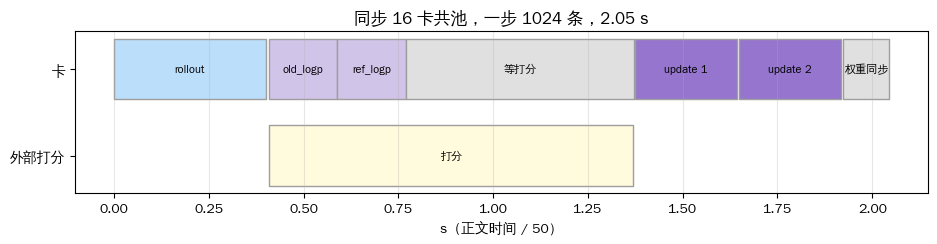

In [52]:
gantt(ev, f'同步 16 卡共池，一步 1024 条，{T:.2f} s', ev[0][2], ['卡', '外部打分'])

### 4.2 异步

**① 跑 8 步**，领先 1 批、每 2 步同步

In [53]:
gen, judge, train = Worker.remote(ASYNC), Judge.remote(ASYNC, seed=1), Worker.remote(ASYNC)
ray.get([gen.get_version.remote(), train.get_version.remote()])
ev, dvs, waits = run_async(gen, judge, train, n_steps=8)
starts = [s for row, label, s, e in ev if label == 'old_logp']          # 每步开始的时刻
win = (starts[6] - starts[2]) / 2                                        # 稳态：第 3 步到第 7 步，平均每两步
print(f'稳态每两步 {win:.2f} s')
print('Δv 序列', dvs)
print('等打分', [round(x, 2) for x in waits], '（第 1 步只有本步前向当预算，等得久；之后预算是一整步 + 前向）')

稳态每两步 1.79 s
Δv 序列 [0, 1, 2, 1, 2, 1, 2, 1]
等打分 [0.74, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0] （第 1 步只有本步前向当预算，等得久；之后预算是一整步 + 前向）


**② 核时间和 Δv**：稳态两步 ≈ 地板（两个前向 + update）× 2 + 权重同步 + 等打分；Δv 从第 3 步起 2、1 交替，平均 1.5。

In [54]:
floor2 = 2 * (ASYNC['old'] + ASYNC['ref'] + ASYNC['update']) + ASYNC['sync']   # 两步的地板 + 一次权重同步
print(f'两步 理论 {floor2:.2f} s + 等打分 {sum(waits[2:6]) / 2:.2f} s，实测 {win:.2f} s')
assert dvs[2:] == [2, 1] * 3 and abs(win - floor2 - sum(waits[2:6]) / 2) < 0.15   # 差的是 Ray 调用开销

两步 理论 1.76 s + 等打分 0.00 s，实测 1.79 s


**③ 甘特**：稳态的两步，和正文异步案例的窗口图对照。

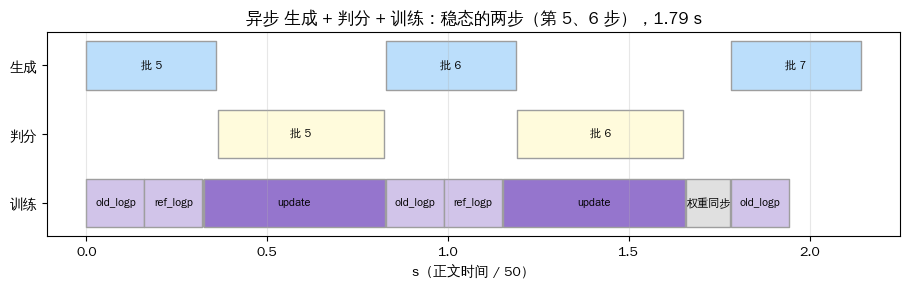

In [55]:
rows = ['生成', '判分', '训练']
gantt(ev, f'异步 生成 + 判分 + 训练：稳态的两步（第 5、6 步），{win:.2f} s', starts[4], rows, t1=starts[6])

**④ 领先 2 批**：Δv 变成 2、3 交替，平均 2.5；预算多一整步，等打分更少。

In [56]:
gen, judge, train = Worker.remote(ASYNC), Judge.remote(ASYNC, seed=1), Worker.remote(ASYNC)
ray.get([gen.get_version.remote(), train.get_version.remote()])
ev2, dvs2, waits2 = run_async(gen, judge, train, n_steps=8, L=2)
print('L = 2 的 Δv 序列', dvs2, ' 平均', sum(dvs2[2:]) / len(dvs2[2:]))
print('等打分', [round(x, 2) for x in waits2])
assert dvs2[2:] == [2, 3] * 3

L = 2 的 Δv 序列 [0, 1, 2, 3, 2, 3, 2, 3]  平均 2.5
等打分 [0.74, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


### 4.3 流式 queue

**① 跑 12 步 ② 看 Δv 的分布**：不再是固定的 1、2，由 max_staleness 兜住上限。

Δv 均值 1.31  分布 Counter({1: 378, 2: 306, 0: 78, 3: 6})


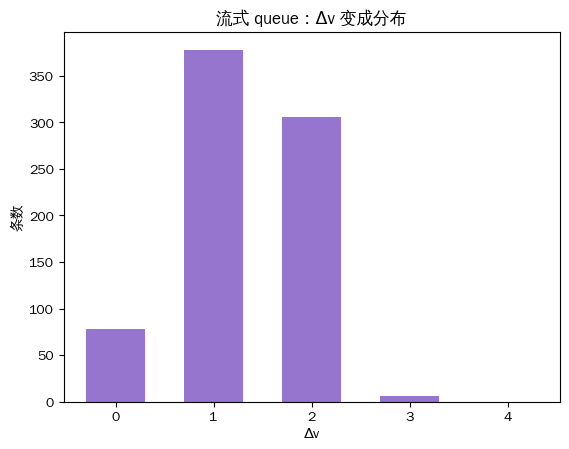

In [57]:
gen, judge, train = GenStream.remote(ASYNC), JudgeStream.remote(ASYNC), Worker.remote(ASYNC)
ray.get([gen.get_version.remote(), train.get_version.remote()])
dvs_s = run_stream(gen, judge, train, n_steps=12)
print('Δv 均值', round(sum(dvs_s) / len(dvs_s), 2), ' 分布', collections.Counter(dvs_s))
plt.hist(dvs_s, bins=range(0, 6), align='left', rwidth=0.6, color='#9575cd'); plt.xlabel('Δv'); plt.ylabel('条数'); plt.title('流式 queue：Δv 变成分布'); plt.show()

## 5. 和真实实现的差别

| 这里 | verl 里 |
| --- | --- |
| `Worker` 的四个方法 | `ActorRolloutRefWorker` 等 worker，方法经 `WorkerGroup` 的 dispatch / collect 落到各 rank |
| `sync_step` | `RayPPOTrainer.fit` 的一步：`generate_sequences → compute_log_prob → compute_ref_log_prob → update_actor` |
| `run_async` 的 in-flight 批 | 异步 rollout 的 `AgentLoop` / `AsyncLLM`，领先批数由 `trigger_parameter_sync_step` 一类参数定 |
| `load_weights` 只拷贝版本号 | 真实权重同步走 checkpoint engine 或 NCCL 广播，见 04 篇 |
| `run_stream` 的 backpressure | AReaL 的 `StalenessManager`，提交前按版本上限限流 |
| 打分 `sleep` | 生成式 RM 的推理服务，拖尾来自回答写满上限、失败重试 |

In [58]:
ray.shutdown()